In [ ]:
# Import Libraries

!pip install --quiet yfinance scipy 

import yfinance as yf 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import norm, t, normaltest, ttest_1samp
import warnings
warnings.filterwarnings("ignore")
import datetime as dt #  Used to set date ranges for fetching stock data.
import os 	  # work with files
import time   #	introduce delays (used in downloading)
import math   # extra math functions (like square root, log base 10)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

In [4]:
# Downloading Data

tickers = ["AAPL", "MSFT", "AMZN", "GOOGL"]
close_df = yf.download(tickers, start= "2024-05-26" , end = "2025-06-26")["Close"]
close_df.columns = [f"{ticker}_Close" for ticker in close_df.columns]
close_df.head(10)

# We downloaded closing prices for 4 selected stocks using yfinance.
# Closing prices are used instead of opening or high/low because they reflect the final market value of a stock for the day
# and are the standard input for calculating daily log returns, which measure consistent percentage change over time.

[*********************100%***********************]  4 of 4 completed


,AAPL_Close,AMZN_Close,GOOGL_Close,MSFT_Close
Date,,,,
2024-05-28,189.105621,182.149994,175.348373,427.045868
2024-05-29,189.404221,182.020004,174.851349,425.904633
2024-05-30,190.399567,179.320007,171.083954,411.514923
2024-05-31,191.355103,176.440002,171.471619,411.971436
2024-06-03,193.126785,178.339996,172.137634,410.373657
2024-06-04,193.445312,179.339996,172.753952,412.904297
2024-06-05,194.958237,181.279999,174.364273,420.783875
2024-06-06,193.574707,185.000000,175.676392,421.289948
2024-06-07,195.973495,184.300003,173.419968,420.625092


In [5]:
# Calculation of Log return

log_return_df = np.log(close_df / close_df.shift(1))
log_return_df.dropna(inplace=True)
log_return_df.columns = [f"{ticker}_log_return" for ticker in log_return_df.columns]
log_return_df.head(5)

# After downloading daily close prices , I calculated the daily log returns using the natural log of today’s price divided by yesterday’s.
# Log returns are preferred in quantitative finance because they add over time, behave more like a normal distribution, and reflect continuous compounding , making them ideal for risk modeling and VaR calculations.
# I removed the first row of missing values and renamed the columns to make it clear that the data now represents log returns .

,AAPL_Close_log_return,AMZN_Close_log_return,GOOGL_Close_log_return,MSFT_Close_log_return
Date,,,,
2024-05-29,0.001578,-0.000714,-0.002839,-0.002676
2024-05-30,0.005241,-0.014945,-0.021782,-0.034370
2024-05-31,0.005006,-0.016191,0.002263,0.001109
2024-06-03,0.009216,0.010711,0.003877,-0.003886
2024-06-04,0.001648,0.005592,0.003574,0.006148


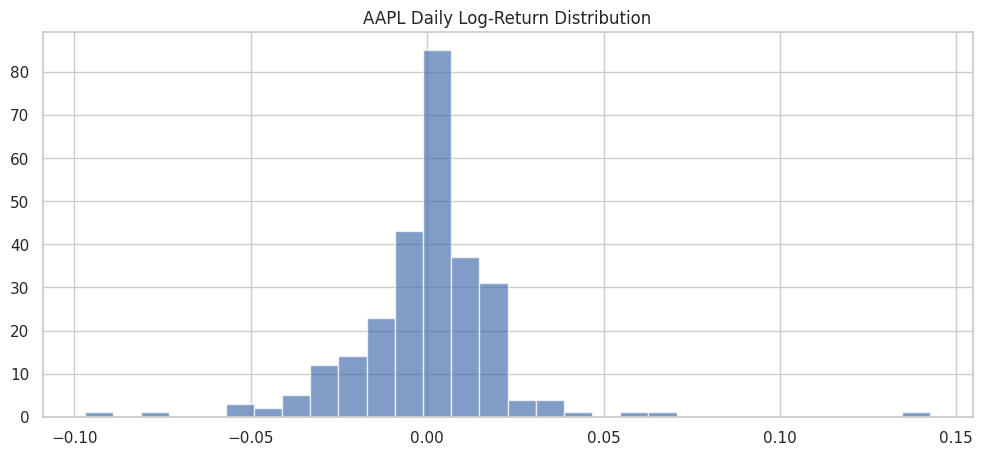

In [6]:
# Histogram

log_return_df['AAPL_Close_log_return'].hist(bins=30, alpha=0.7)
plt.title('AAPL Daily Log-Return Distribution')
plt.show()

# I plotted a histogram of Apple’s daily log returns to visually inspect the distribution.
# This gave me an early sense of whether the returns were symmetric, normal, or had extreme values (fat tails).
# This visual check helped guide my choice of statistical models later — for example, deciding whether a normal or Student’s t-distribution would be a better fit for VaR.

In [7]:
# Summary of Log return

summary_df = pd.DataFrame({
    "Mean": log_return_df.mean(),
    "Std": log_return_df.std(),
    "Variance": log_return_df.var(),
    "Skewness": log_return_df.skew(),
    "Kurtosis": log_return_df.kurt()
})
summary_df

# Created a DataFrame with key statistical metrics:
#  Mean: average daily log return
#  Std: standard deviation (volatility / risk)
#  Variance: spread of returns (square of std)
#  Skewness: asymmetry in returns (direction of extreme values)
#  Kurtosis: tail risk (frequency of extreme values)

,Mean,Std,Variance,Skewness,Kurtosis
AAPL_Close_log_return,0.000237,0.020175,0.000407,0.618231,11.564521
AMZN_Close_log_return,0.000564,0.021300,0.000454,0.006133,5.113575
GOOGL_Close_log_return,-0.000100,0.019641,0.000386,-0.222088,2.897660
MSFT_Close_log_return,0.000528,0.015719,0.000247,0.514161,7.855418


In [8]:
# Applying Normal Distribution

portfolio_returns = log_return_df.values.flatten()
portfolio_returns = portfolio_returns[~np.isnan(portfolio_returns)]
mean_return = np.mean(portfolio_returns)
print("Mean Daily Return (μ):", mean_return)
std_dev = stats.sem(portfolio_returns)
print("Standard Deviation (σ):", std_dev)

n = len(portfolio_returns)
z = norm.ppf(0.975)  # z-score for 95% CI
margin_of_error = z * (std_dev / np.sqrt(n))
ci_mean_lower = mean_return - margin_of_error
ci_mean_upper = mean_return + margin_of_error

print("95% Confidence Interval for Mean:")
print(f"({ci_mean_lower:.5f}, {ci_mean_upper:.5f})")

df = n - 1
from scipy.stats import chi2
chi2_lower = chi2.ppf(0.025, df)
chi2_upper = chi2.ppf(0.975, df)
ci_std_lower = np.sqrt((df * std_dev**2) / chi2_upper)
ci_std_upper = np.sqrt((df * std_dev**2) / chi2_lower)

print("95% Confidence Interval for Standard Deviation:")
print(f"({ci_std_lower:.5f}, {ci_std_upper:.5f})")

# Fitted Normal distribution to portfolio returns and calculated 95% CI for mean and std — needed for normal VaR .

Mean Daily Return (μ): 0.00030728777151260445
Standard Deviation (σ): 0.0005883158236689382
95% Confidence Interval for Mean:
(0.00027, 0.00034)
95% Confidence Interval for Standard Deviation:
(0.00056, 0.00061)


In [9]:
# Fitting Student's t-distribution

df_t, loc, scale = stats.t.fit(portfolio_returns)

print(f"\nStudent's t-Distribution Fit:")
print(f"μ (mean): {loc:.5f}")
print(f"σ (std deviation): {scale:.5f}")
print(f"df (degrees of freedom): {df_t:.3f}")

# Fitted Student's t-distribution to portfolio returns — gives mean, std, and degrees of freedom for t-based VaR.


Student's t-Distribution Fit:
μ (mean): 0.00107
σ (std deviation): 0.01281
df (degrees of freedom): 3.453


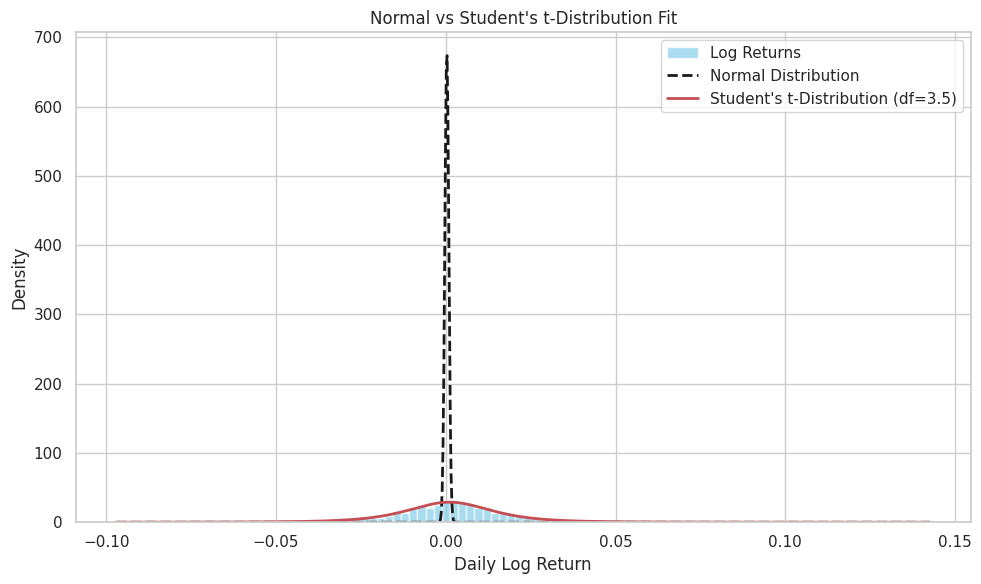

In [10]:
# Compare Normal vs Student's t visually

x = np.linspace(min(portfolio_returns), max(portfolio_returns), 1000)
pdf_normal = stats.norm.pdf(x, loc=mean_return, scale=std_dev)
pdf_t = stats.t.pdf(x, df=df_t, loc=loc, scale=scale)
plt.figure(figsize=(10, 6))
plt.hist(portfolio_returns, bins=100, density=True, alpha=0.7, label="Log Returns", color="skyblue")
plt.plot(x, pdf_normal, 'k--', lw=2, label="Normal Distribution")
plt.plot(x, pdf_t, 'r-', lw=2, label=f"Student's t-Distribution (df={df_t:.1f})")
plt.title("Normal vs Student's t-Distribution Fit")
plt.xlabel("Daily Log Return")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# This plot visually compares how well the Normal vs. t-distribution models fit the actual return data.
# The Student’s t-distribution captures the fat tails better — making it a more realistic model for risk.

In [11]:
# Bootstrapped 95% Confidence Intervals
num_bootstraps = 1000
n = len(portfolio_returns)

bootstrap_means = []
bootstrap_stds = []

for _ in range(num_bootstraps):
    sample = np.random.choice(portfolio_returns, size=n, replace=True)
    df_t, loc, scale = t.fit(sample)
    bootstrap_means.append(loc)
    bootstrap_stds.append(scale)

ci_mu = np.percentile(bootstrap_means, [2.5, 97.5])
ci_sigma = np.percentile(bootstrap_stds, [2.5, 97.5])

print("Bootstrapped 95% Confidence Intervals (Student's t):")
print(f"Mean Estimate (μ)       : {np.mean(bootstrap_means):.5f}")
print(f"95% CI for Mean (μ)     : ({ci_mu[0]:.6f}, {ci_mu[1]:.5f})\n")
print(f"Std Dev Estimate (σ)    : {np.mean(bootstrap_stds):.5f}")
print(f"95% CI for Std Dev (σ)  : ({ci_sigma[0]:.6f}, {ci_sigma[1]:.5f})")

# Earlier, we used analytical CI formulas assuming the data is Normally distributed.
# But in reality, returns often have fat tails — so we used bootstrapping with t-distribution to empirically estimate the confidence intervals.
# This gives us a more realistic view of risk and parameter uncertainty.”

Bootstrapped 95% Confidence Intervals (Student's t):
Mean Estimate (μ)       : 0.00109
95% CI for Mean (μ)     : (0.000167, 0.00202)

Std Dev Estimate (σ)    : 0.01282
95% CI for Std Dev (σ)  : (0.011896, 0.01370)


In [12]:
# Normal Var (Parametric)

confidence_level = 0.95
alpha = 1 - confidence_level
mean_normal = np.mean(portfolio_returns)
std_normal = np.std(portfolio_returns, ddof=1)
z_score = norm.ppf(alpha)
var_normal = -(mean_normal + z_score * std_normal)

print(f"Parametric VaR (Normal) at {int(confidence_level*100)}% confidence:")
print(f"VaR (1-day): {var_normal:.5f}")

# This is the 1-day Value at Risk using the Parametric Normal method.
# I assumed returns follow a Normal distribution and used the mean, standard deviation, and z-score for 95% confidence.
# It gives the maximum expected daily loss with 95% certainty.

Parametric VaR (Normal) at 95% confidence:
VaR (1-day): 0.03144


In [13]:
# T- Var (Parametric)

df_t, loc_t, scale_t = t.fit(portfolio_returns)
t_critical = t.ppf(alpha, df_t)
var_t = -(loc_t + t_critical * scale_t)

print(f"\nParametric VaR (Student’s t) at {int(confidence_level*100)}% confidence:")
print(f"VaR (1-day): {var_t:.5f}")

# This is the 1-day Parametric VaR using the Student’s t-distribution, which handles fat tails better than the normal model.
# I used the fitted mean, scale, and degrees of freedom along with the t-critical value to compute the expected daily loss at 95% confidence.


Parametric VaR (Student’s t) at 95% confidence:
VaR (1-day): 0.02752


In [14]:
# Historical method

var_historical = -np.percentile(portfolio_returns, (1 - confidence_level) * 100)

print(f"\nHistorical VaR at {int(confidence_level*100)}% confidence:")
print(f"VaR (1-day): {var_historical:.5f}")

# This is the 1-day Historical VaR, which doesn’t assume any distribution.
# It directly takes the 5th percentile of past returns to estimate the worst expected daily loss with 95% confidence.
# Its useful as a model-free reality check against the Normal and t-based VaR.


Historical VaR at 95% confidence:
VaR (1-day): 0.03122


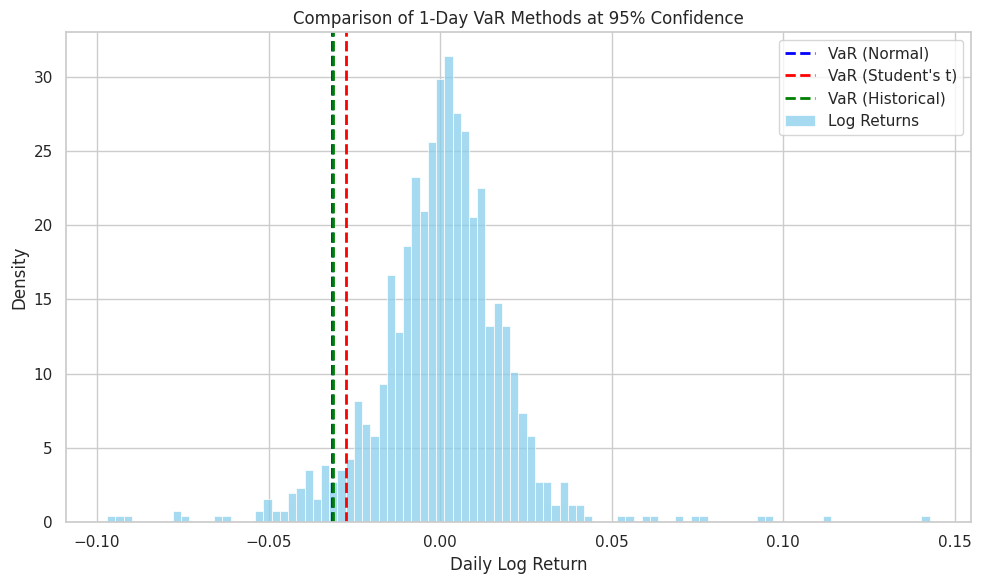

In [15]:
# Comparison of Parametric and Historic VaR

plt.figure(figsize=(10, 6))
sns.histplot(portfolio_returns, bins=100, kde=False, color="skyblue", stat="density", label="Log Returns")
plt.axvline(-var_normal, color='blue', linestyle='--', linewidth=2, label='VaR (Normal)')
plt.axvline(-var_t, color='red', linestyle='--', linewidth=2, label="VaR (Student's t)")
plt.axvline(-var_historical, color='green', linestyle='--', linewidth=2, label='VaR (Historical)')
plt.title("Comparison of 1-Day VaR Methods at 95% Confidence")
plt.xlabel("Daily Log Return")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# In practice, the Student’s t-based VaR is often more reliable because it accounts for fat tails in financial return distributions — which the Normal model underestimates.
# The Historical VaR is also useful as a model-free reality check, since it reflects actual past losses.
# I’d compare all three, but prefer Student’s t for its balance between theory and realism
# Historical VaR is realistic because it uses actual past data — but it can understate future risk if that data didn’t include extreme events.
# That’s why I prefer Student’s t-based VaR, which models heavy tails and can better estimate large losses — especially in crisis-prone assets.”

In [16]:
# Hypothesis Testing

from scipy.stats import ttest_1samp
t_stat, p_value = ttest_1samp(portfolio_returns, popmean=0)

print("One-Sample t-Test for Portfolio Mean Return")
print(f"t-statistic: {t_stat:.5f}")
print(f"p-value    : {p_value:.5f}")

# I ran a one-sample t-test to check if the portfolio’s average daily return is significantly different from zero.
# The p-value is 0.60, which is much greater than 0.05, so we fail to reject the null hypothesis.
# This means the portfolio’s mean return is not statistically significant — it could be close to zero due to randomnes

One-Sample t-Test for Portfolio Mean Return
t-statistic: 0.52232
p-value    : 0.60156


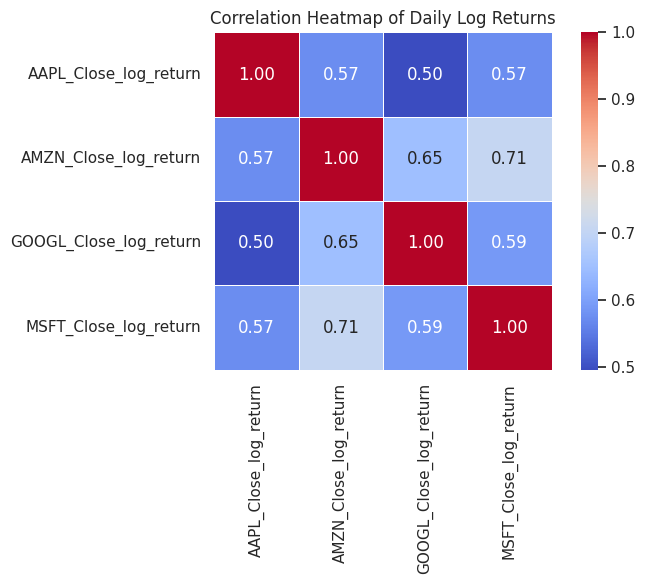

In [17]:
# Correlation
correlation_matrix = log_return_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5, square=True, fmt=".2f")
plt.title("Correlation Heatmap of Daily Log Returns")
plt.tight_layout()
plt.show()

# Most correlation values are in the 0.50–0.71 range, meaning these stocks move quite similarly.
# As a result, even though we built a multi-asset portfolio, the benefit of diversification was very limited.
# To improve diversification, we would need to include assets that are less correlated or from different sectors

In [23]:
# Diversification Benefit

individual_std = log_return_df.std()
print("Standard Deviation of Each Stock\n",individual_std)
weights = np.array([0.25, 0.25, 0.25, 0.25])  # equal weights
weighted_std_no_diversification = np.dot(individual_std, weights)
print(f"\nWeighted Average Std Dev (No Diversification): {weighted_std_no_diversification:.5f}")
actual_portfolio_std = portfolio_returns.std()
print(f"Actual Portfolio Std Dev (With Diversification): {actual_portfolio_std:.5f}")
diversification_benefit = weighted_std_no_diversification - actual_portfolio_std
print(f"Diversification Benefit: {diversification_benefit:.5f}")

# The actual standard deviation of the portfolio was slightly higher than the expected value.
# Therefore, we found no diversification benefit in this particular portfolio setup.
# This may be due to high correlation among stocks and the use of equal weighting without risk-adjustment.

Standard Deviation of Each Stock
 AAPL_Close_log_return     0.020175
AMZN_Close_log_return     0.021300
GOOGL_Close_log_return    0.019641
MSFT_Close_log_return     0.015719
dtype: float64

Weighted Average Std Dev (No Diversification): 0.01921
Actual Portfolio Std Dev (With Diversification): 0.01614
Diversification Benefit: 0.00307


In [19]:
# Max Drawdown

simple_returns_df = np.exp(log_return_df) - 1
weights = np.array([0.25, 0.25, 0.25, 0.25])
portfolio_returns = simple_returns_df.dot(weights)
cumulative_returns = (1 + portfolio_returns).cumprod()
running_max = cumulative_returns.cummax()
drawdown = (cumulative_returns - running_max) / running_max
max_drawdown = drawdown.min()
max_drawdown_date = drawdown.idxmin()

print(f"Max Drawdown: {max_drawdown:.4%}")
print(f"Max Drawdown Date: {max_drawdown_date.date()}")

# The maximum drawdown observed was −26.16%, which occurred on April 8, 2025.
# This means an investor would have seen their portfolio fall by over a quarter from its highest point before recovery.
# This metric captures the emotional stress and risk exposure of holding the portfolio long-term.

Max Drawdown: -26.1597%
Max Drawdown Date: 2025-04-08


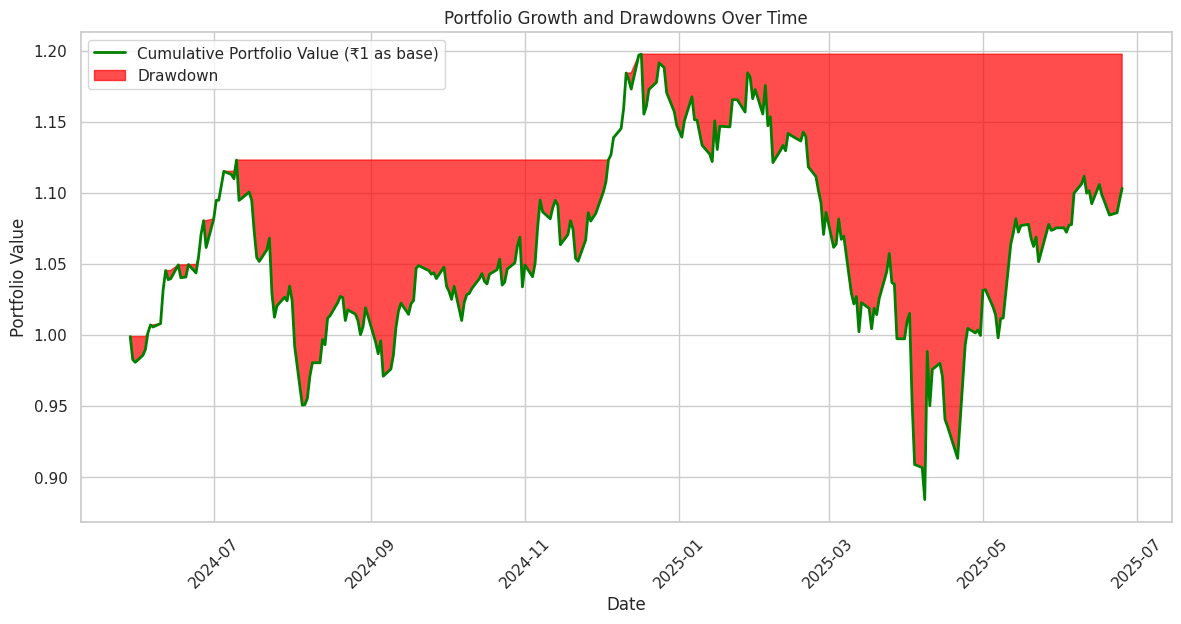

In [24]:
# Portfolio Growth and Drawdowns Over Time

plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns, label="Cumulative Portfolio Value (₹1 as base)", color="green", linewidth=2)
plt.fill_between(drawdown.index, cumulative_returns, running_max,
                 where=cumulative_returns < running_max,
                 interpolate=True, color='red', alpha=0.7, label="Drawdown")

plt.title("Portfolio Growth and Drawdowns Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

# This plot shows how the portfolio grew over time starting from ₹1, and visually highlights periods of drawdown
# when the portfolio dropped from its peak value.
# It helps investors understand not just how much was earned, but how deep and long the losses were during rough periods.”

In [25]:
# Recovery Time

drawdown            = (cumulative_returns - running_max) / running_max
max_dd_date         = drawdown.idxmin()

peak_before_plunge  = running_max[max_dd_date]
recovery_date = cumulative_returns[max_dd_date:].loc[
    cumulative_returns[max_dd_date:] >= peak_before_plunge
].first_valid_index()
if recovery_date is not None:
    recovery_days = (recovery_date - max_dd_date).days
    print(f"📉 Max drawdown: {drawdown[min(drawdown.index)]:.2%}")
    print(f"📅 Max-DD date : {max_dd_date.date()}")
    print(f"📈 Recovery date: {recovery_date.date()}")
    print(f"⏳ Recovery time: {recovery_days} days")
else:
    print("The portfolio has not yet climbed back to its previous peak.")
    print(f"Max drawdown: {drawdown[min(drawdown.index)]:.4%}")
    print(f"Max-DD date : {max_dd_date.date()}")

# The portfolio experienced its maximum drawdown of −26.16% on April 8, 2025.
# As of the latest available data (June 26, 2025), the portfolio has not yet recovered to its previous peak value of ₹0.8842.
# This indicates that the drawdown was not only deep but also prolonged, showing a significant recovery lag — a critical risk insight for long-term investors.

The portfolio has not yet climbed back to its previous peak.
Max drawdown: 0.0000%
Max-DD date : 2025-04-08


In [26]:
# CVaR (Historic)

simple_returns = np.exp(portfolio_returns) - 1
sorted_returns = np.sort(simple_returns)
cutoff_index = int(0.05 * len(sorted_returns))
historical_cvar = sorted_returns[:cutoff_index].mean()

print(f"Historical CVaR (95%): {historical_cvar:.4%}")

Historical CVaR (95%): -3.6383%


In [27]:
# Parametric CVaR

mu = simple_returns.mean()
sigma = simple_returns.std()
alpha = 0.95
z = norm.ppf(1 - alpha)
pdf_z = norm.pdf(z)
parametric_cvar = -mu + sigma * (pdf_z / (1 - alpha))

print(f"Parametric CVaR (95%): {parametric_cvar:.4%}")

# The Historical Expected Shortfall (CVaR) at 95% confidence was found to be −3.64%, while the Parametric CVaR (based on a normal distribution) was +3.30%.
# This clearly shows that the normal model underestimates real-world risk, as actual market data includes more extreme negative returns.
# The analysis tells the importance of using historical methods for risk assessment, especially during volatile market conditions.

Parametric CVaR (95%): 3.2967%


In [28]:
# VaR Backtesting

historical_var_95 = np.percentile(simple_returns, 5)
exceptions = simple_returns < historical_var_95
num_exceptions = exceptions.sum()
total_days = len(simple_returns)
exception_rate = (num_exceptions / total_days) * 100

print(f"Total Trading Days: {total_days}")
print(f"Number of Exceptions: {num_exceptions}")
print(f"Historical VaR (95%): {historical_var_95:.4%}")
print(f"Exception Rate: {exception_rate:.4f}%")

# Our backtest observed 14 exceptions, resulting in an exception rate of 5.20%, which is very close to the expected value (5%).
# This indicates that the model is well-calibrated, and the 95% Historical VaR accurately captures the risk of extreme negative returns.

Total Trading Days: 269
Number of Exceptions: 14
Historical VaR (95%): -2.4858%
Exception Rate: 5.2045%


In [29]:
# 60-day rolling historical VaR (5% worst-case)

rolling_var_95 = simple_returns.rolling(window=60).quantile(0.05)
static_var_95 = np.percentile(simple_returns, 5)

# This calculates a rolling 60-day Historical VaR using the 5th percentile of returns in each window.
# It helps visualize how the portfolio’s short-term risk evolves over time, especially during volatile periods

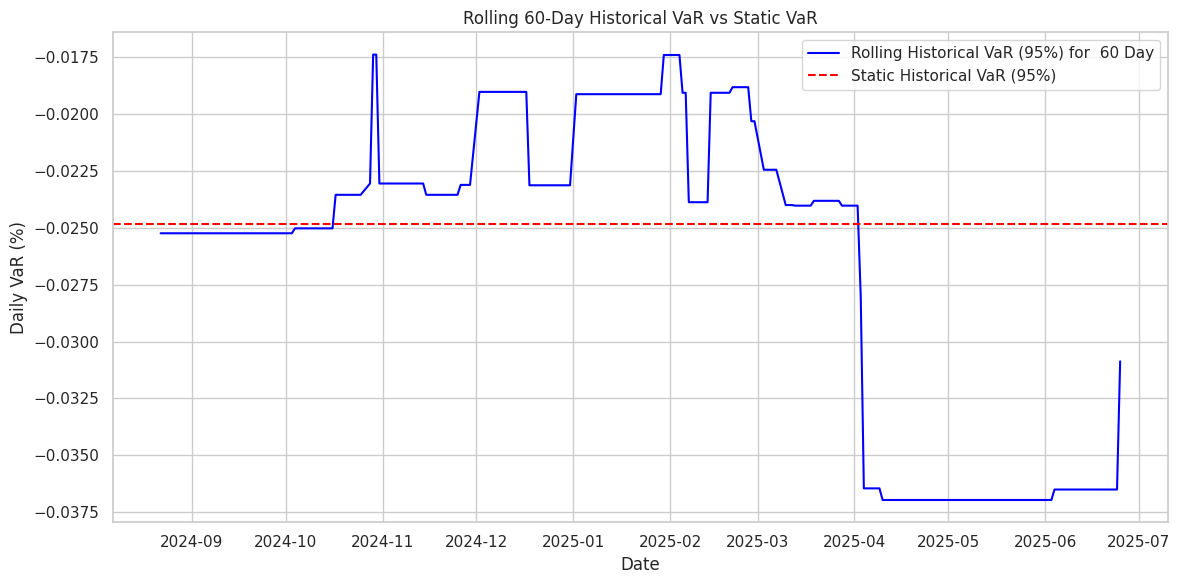

In [30]:
# Rolling 60-Day Historical VaR vs Static VaR

plt.figure(figsize=(12, 6))
plt.plot(rolling_var_95, label='Rolling Historical VaR (95%) for  60 Day', color='blue')
plt.axhline(y=static_var_95, color='red', linestyle='--', label='Static Historical VaR (95%)')
plt.title('Rolling 60-Day Historical VaR vs Static VaR')
plt.xlabel('Date')
plt.ylabel('Daily VaR (%)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# This plot compares the rolling 60-day Historical VaR with the static VaR.
# It shows how portfolio risk is not constant — it increases in volatile periods and drops in stable times.
# This kind of rolling analysis helps in making dynamic risk management decisions.

In [31]:
# Jarque-Bera Test

from scipy.stats import jarque_bera
jb_stat, p_value = jarque_bera(portfolio_returns)

print("Jarque-Bera Normality Test Results:")
print(f"JB Statistic : {jb_stat:.4f}")
print(f"p-value      : {p_value:.4f}")
if p_value < 0.05:
    print("Reject the null hypothesis returns don't follow a normal distribution.")
    print("Use t-distribution or historical models instead of normal-based risk models.")
else:
    print("\n Cannot reject normality returns may follow a normal distribution.")
    print(" Parametric models based on normal distribution may be suitable.")

# The test returned a p-value of 0.024, indicating we reject the null hypothesis.
# This means our portfolio returns do not follow a normal distribution.
# Conclusion: Models assuming normality (e.g., Parametric VaR) may underestimate risk.
# It’s advisable to use t-distribution or historical methods which better capture real-world volatility and “fat tails”.

Jarque-Bera Normality Test Results:
JB Statistic : 1289.9674
p-value      : 0.0000
Reject the null hypothesis returns don't follow a normal distribution.
Use t-distribution or historical models instead of normal-based risk models.
